In [241]:
from exo_model import ExoModel
from fit_exo import calculate_template_length_distribution

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns

In [257]:
import pysam
from collections import Counter
from dataclasses import dataclass


class BamData:
    def __init__(self, controller):
        self.controller = controller
        
    def get_tlen_counts(self, norm=True, min_tlen=0, max_tlen=200):
        # Словарь для хранения распределения длин
        length_dist = Counter()
        alignment_file = self.controller._get_alignment_file()
        for read in alignment_file:
            # Проверяем, что read является парным и правильно выровненным
            if read.is_paired and read.is_proper_pair and read.template_length > 0:
                # Берем абсолютное значение длины шаблона
                tl = read.template_length
                length_dist[tl] += 1
        if norm:
            length_dist = {k: v / sum(length_dist.values()) for k, v in length_dist.items() if min_tlen <= k <= max_tlen}
        alignment_file.close()
        return length_dist


class BamFileController:
    def __init__(self, bam_path):
        self.bam_path = self._validate_bam(bam_path)
        
    def count_bam_statistics(self):
        return BamData(self)
        
    def _get_alignment_file(self, need_index=False):
        if need_index:
            pysam.index(self.bam_path)
        alignment_file = pysam.AlignmentFile(self.bam_path)
        return alignment_file
    
    def _validate_bam(self, bam_path):
        alignment_file = pysam.AlignmentFile(bam_path)
        if not alignment_file.has_index():
            pysam.index(bam_path)
        return bam_path

    
  

In [258]:
bam_file = "/home/d_ryabov/MiSeq/NucDPOsIT_analysis/yeast_data/reads_output/SRR1802184/SRR1802185_99_147_sorted.bam"

In [259]:
c = BamFileController(bam_file)

In [260]:
bam_data = c.count_bam_statistics()

In [261]:
s = bam_data.get_tlen_counts()

In [256]:
s

{156: 0.008039188291022504,
 157: 0.006222238736582694,
 127: 0.013419910584045274,
 120: 0.005327348930025158,
 153: 0.012736795972319307,
 170: 0.003623589565926359,
 138: 0.011120345550105937,
 96: 0.0010524325098120537,
 145: 0.07999539507081421,
 126: 0.016938579072207718,
 133: 0.021081404473332167,
 137: 0.015279601785312144,
 160: 0.004986489666132968,
 144: 0.05684026898886258,
 185: 0.0022940880892454176,
 149: 0.02269012273833059,
 135: 0.024585252993499295,
 119: 0.004248498216395374,
 131: 0.010173585855564807,
 125: 0.019403955921978668,
 123: 0.016160638143526234,
 124: 0.019739660414394226,
 130: 0.008072694305620602,
 141: 0.007756857161604556,
 134: 0.025186750390178612,
 118: 0.004316476765243438,
 154: 0.012435564014153714,
 199: 0.0009303288604593696,
 146: 0.08012533826845426,
 166: 0.003421264785468613,
 177: 0.0026982006947987606,
 143: 0.028529082737411324,
 103: 0.003191555281541268,
 155: 0.010221374882796069,
 115: 0.00685122824780404,
 147: 0.06140707434393

<Axes: >

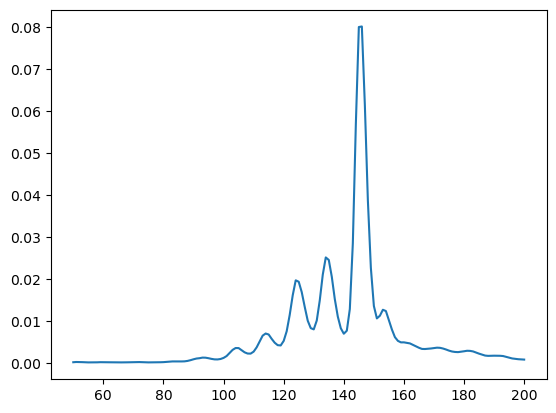

In [262]:
sns.lineplot(s)

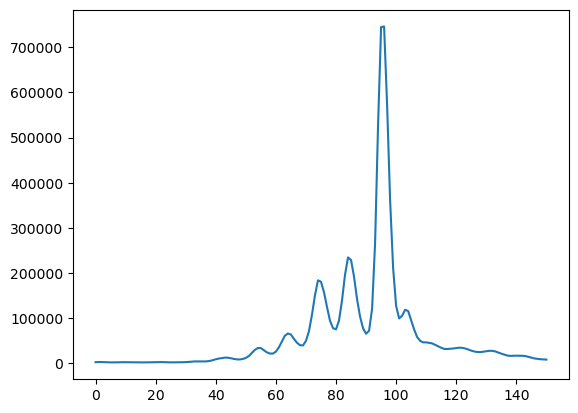

In [107]:
hist = [bam_data.length_dist[i] for i in range(50, 201)]
plt.plot(hist)

In [119]:
model = ExoModel(reg_koef=0)

In [120]:
model.fit(hist)

ExoModel(reg_koef=0)

In [122]:
model.optimization_

 message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: 2554983019601.0
       x: [ 1.316e-02  1.316e-02 ...  1.316e-02  1.316e-02]
     nit: 2000
    nfev: 306081
    njev: 27
    nhev: 0